In [1]:
%run "01_Data Loading.ipynb"

All imports successful
Train shape : (2666, 20)
Test  shape : (667, 20)

Column dtypes:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Missing values: 0


In [2]:
# Class distribution
churn_counts = train['Churn'].value_counts()
print("Churn distribution (train):")
print(churn_counts)
print(f"\nChurn rate: {train['Churn'].mean()*100:.1f}%")

train.describe()

Churn distribution (train):
Churn
False    2278
True      388
Name: count, dtype: int64

Churn rate: 14.6%


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


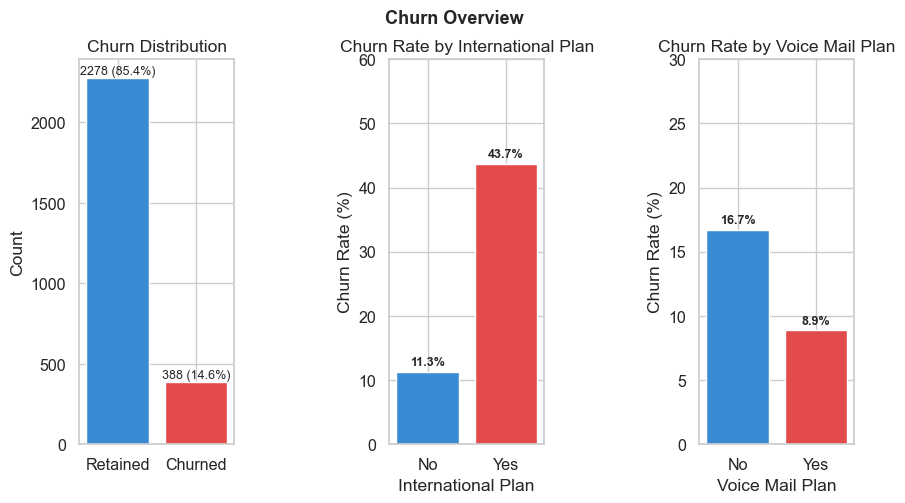

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle('Churn Overview', fontsize=13, fontweight='bold')

# Churn distribution 
churn_counts = train['Churn'].value_counts()
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=['#3B8BD4', '#E24B4A'], edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, f'{v} ({v/len(train)*100:.1f}%)',
                 ha='center', fontsize=9)

# Churn rate by International plan 
ip_churn = train.groupby('International plan')['Churn'].mean() * 100
bars = axes[1].bar(ip_churn.index, ip_churn.values,
                   color=['#3B8BD4', '#E24B4A'], edgecolor='white')
axes[1].set_title('Churn Rate by International Plan')
axes[1].set_xlabel('International Plan')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
for bar, val in zip(bars, ip_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Churn rate by Voice mail plan 
vm_churn = train.groupby('Voice mail plan')['Churn'].mean() * 100
bars = axes[2].bar(vm_churn.index, vm_churn.values,
                   color=['#3B8BD4', '#E24B4A'], edgecolor='white')
axes[2].set_title('Churn Rate by Voice Mail Plan')
axes[2].set_xlabel('Voice Mail Plan')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_ylim(0, 30)
for bar, val in zip(bars, vm_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.subplots_adjust(wspace=1)
plt.show()

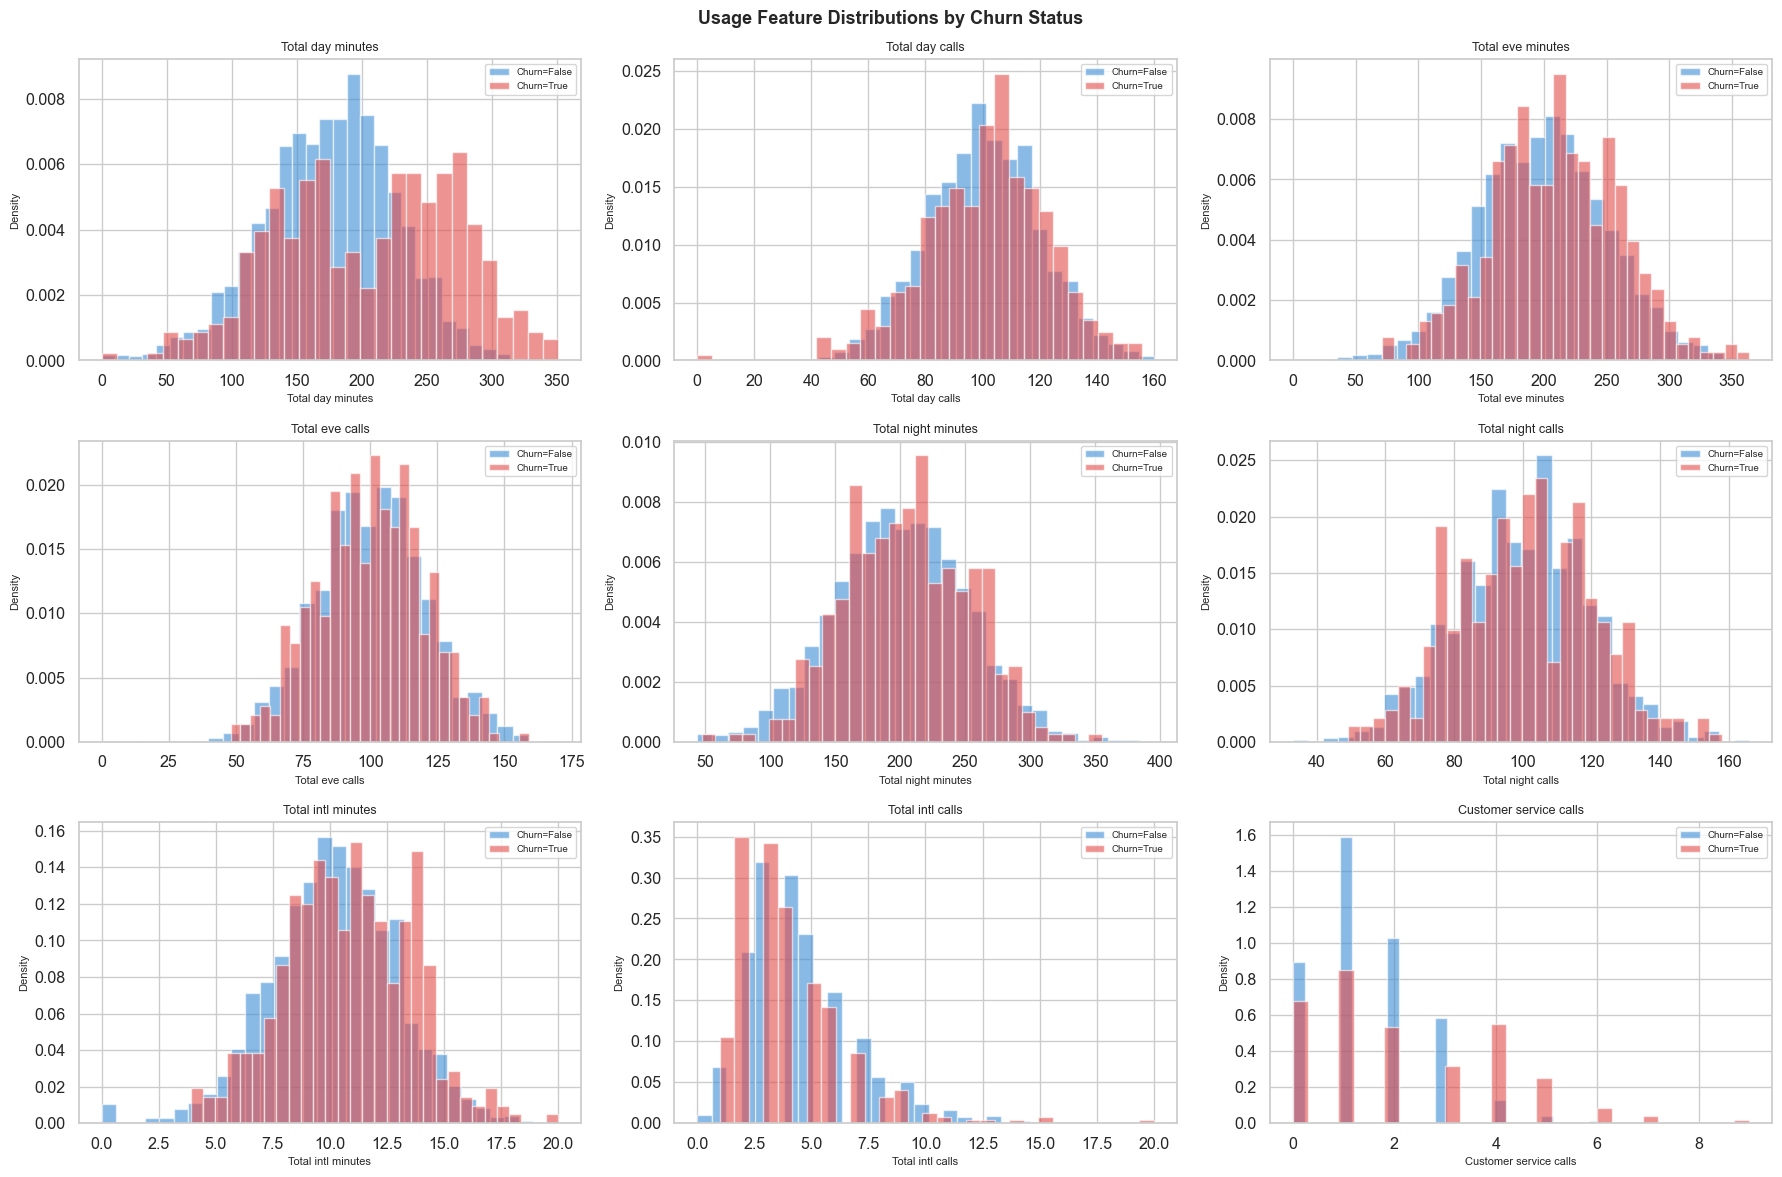

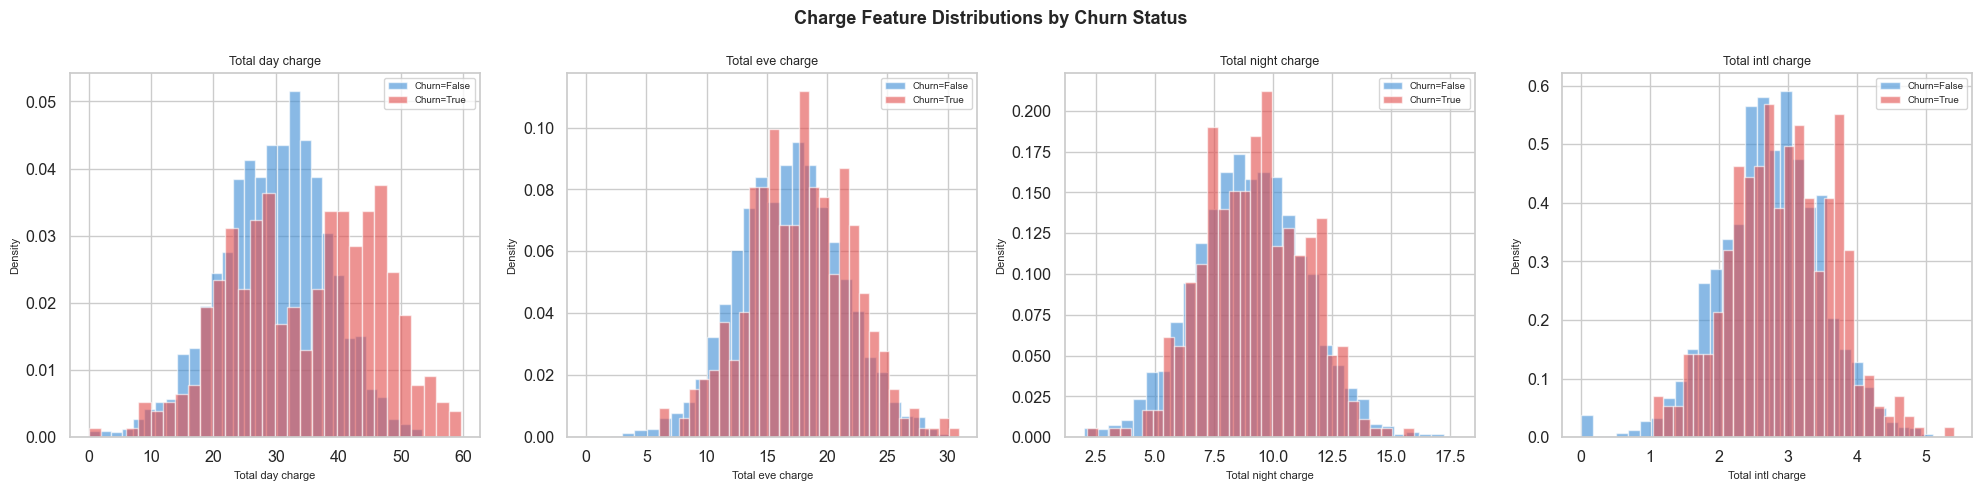

In [60]:
# Feature distributions by churn status
usage_features = [
    'Total day minutes',   'Total day calls',
    'Total eve minutes',   'Total eve calls',
    'Total night minutes', 'Total night calls',
    'Total intl minutes',  'Total intl calls',
    'Customer service calls'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Usage Feature Distributions by Churn Status', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), usage_features):
    for val, color in [('False', '#3B8BD4'), ('True', '#E24B4A')]:
        sub = train[train['Churn'].astype(str) == val][col]
        ax.hist(sub, bins=30, alpha=0.6, color=color, label=f'Churn={val}', density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

charge_features = [
    'Total day charge',
    'Total eve charge',
    'Total night charge',
    'Total intl charge'
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Charge Feature Distributions by Churn Status', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), charge_features):
    for val, color in [('False', '#3B8BD4'), ('True', '#E24B4A')]:
        sub = train[train['Churn'].astype(str) == val][col]
        ax.hist(sub, bins=30, alpha=0.6, color=color, label=f'Churn={val}', density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

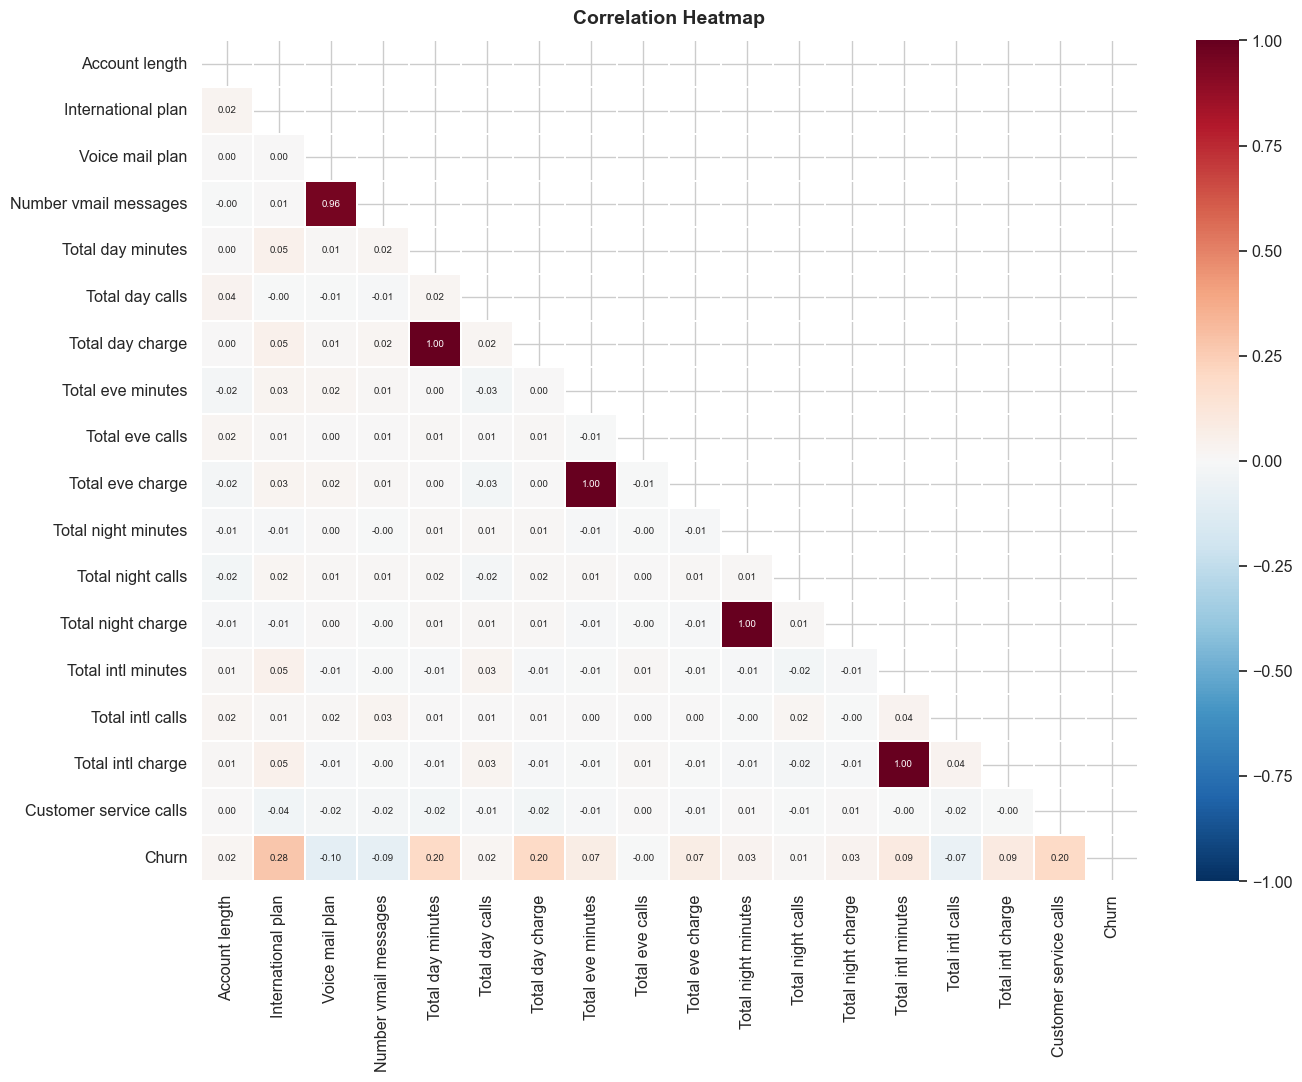

In [61]:
# Correlation heatmap
df_corr = train.copy()
df_corr['Churn']              = df_corr['Churn'].astype(int)
df_corr['International plan'] = LabelEncoder().fit_transform(df_corr['International plan'])
df_corr['Voice mail plan']    = LabelEncoder().fit_transform(df_corr['Voice mail plan'])
df_corr.drop(columns=['State','Area code'], inplace=True)

corr = df_corr.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size':7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()